# From MATLAB docs: "With L1 normalization, if you have equal amplitude oscillatory components in your data at different scales, they will have equal magnitude in the CWT." [link](https://se.mathworks.com/help/wavelet/ref/cwt.html#:~:text=With%20L1%20normalization%2C%20if%20you%20have%20equal%20amplitude%20oscillatory%20components%20in%20your%20data%20at%20different%20scales%2C%20they%20will%20have%20equal%20magnitude%20in%20the%20CWT)

# This notebook shows that this is not so for noisy signals and low oscillation amplitude

## How does CWT amplitude (at the peak) depend on frequency in noisy data? For noiseless data and L1 normalization amplitude doesn't change with frequency.

In [35]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append('../../wavelet/')
import wavelet_funcs as wf

path.append('../../signals/')
import signals as sg

import matlab.engine
import xarray as xr

In [3]:
eng = matlab.engine.start_matlab()

# Synthetic signal:

$$
z = a \cos(2\pi f_1 t) + \epsilon,
$$

where $f_1$ is frequency in Hz, varied; $a$ is amplitude (constant for varied $f$); $\epsilon \sim N(0, 1)$ (white noise).

# Case 1: Amplitude is high

In [82]:
T = 1500 # s
dt = 0.1 # s
Fs = 1/dt
nt = int(T/dt)
fsignals = np.arange(0.05, 3, 0.2)
a = 3

t = np.arange(nt)*dt
y = np.random.randn(nt) # noise
x = np.array([sg.cosine(T, fsig, sampling_frequency=Fs, amplitude=a)[1] + y for fsig in fsignals])

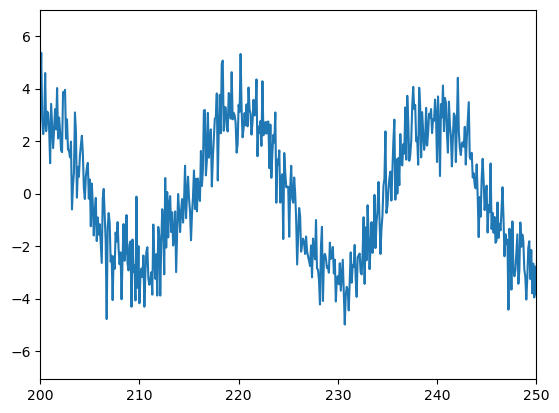

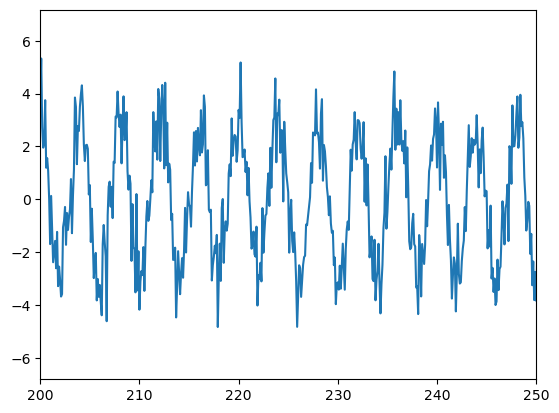

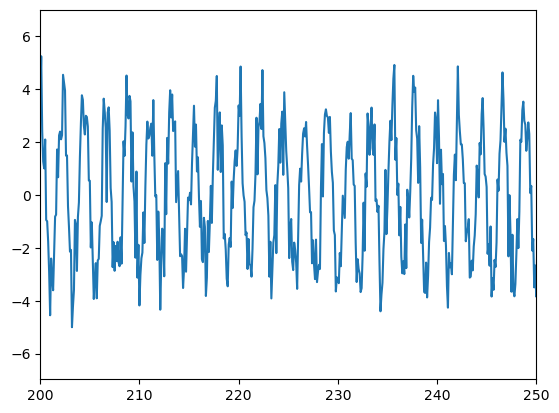

In [83]:
for xi in x[:3]:
    plt.figure()
    plt.plot(t, xi)
    plt.xlim(200, 250)

In [88]:
spectra = []
for xi in x:
    res = wf.matlab_cwt(eng, xi, Fs, voices_per_octave=24)
    spec = res.wt_amp.mean('t')
    spectra.append(spec)

spectra = xr.concat(spectra, dim='sig').assign_coords(fsig=('sig', fsignals))

(<Figure size 1000x400 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.QuadMesh at 0x35e16ee90>)

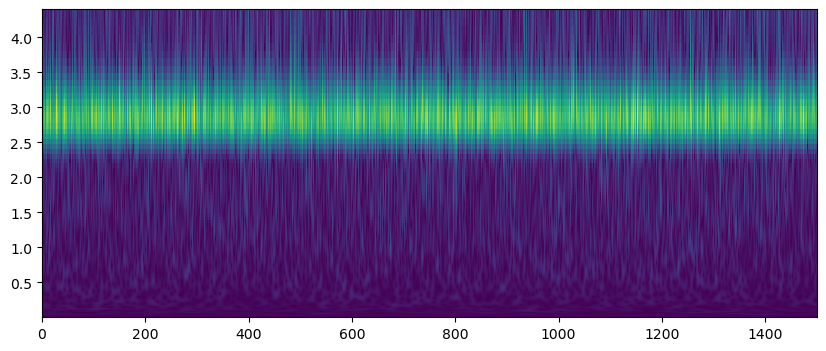

In [89]:
wf.plot_cwt(res.wt_amp, res.f, res.t)

[Text(0.5, 0, 'Frequency (Hz)'),
 Text(0, 0.5, 'Signal oscillation frequency (Hz)')]

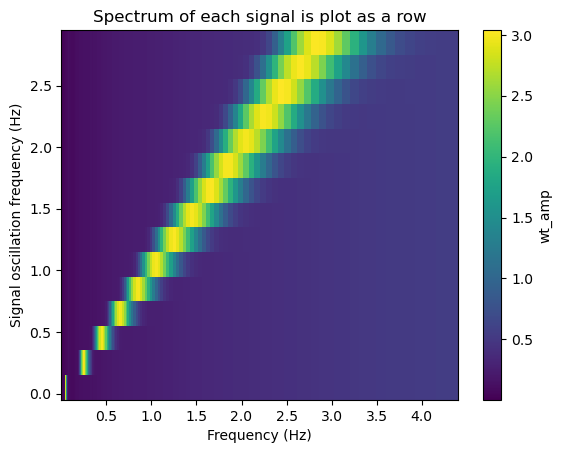

In [72]:
spectra.plot(y='fsig')
plt.title('Spectrum of each signal is plot as a row')
plt.gca().set(xlabel='Frequency (Hz)', ylabel='Signal oscillation frequency (Hz)')

[Text(0.5, 0, 'Frequency (Hz)'), Text(0, 0.5, 'Wavelet amplitude')]

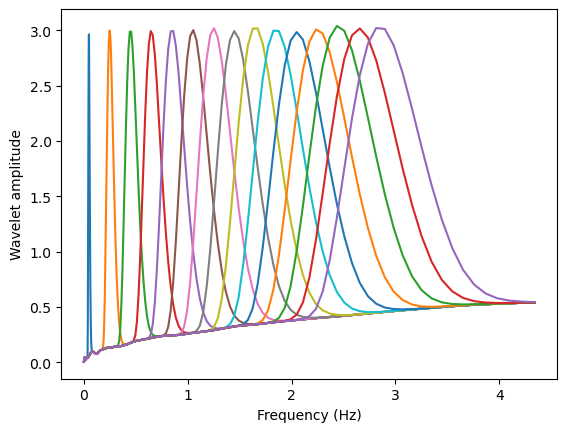

In [73]:
spectra.plot.line(hue='fsig', add_legend=False);
plt.gca().set(xlabel='Frequency (Hz)', ylabel='Wavelet amplitude')

# Case 2: Amplitude is low

In [90]:
T = 1500 # s
dt = 0.1 # s
Fs = 1/dt
nt = int(T/dt)
fsignals = np.arange(0.05, 3, 0.2)
a = 0.3

t = np.arange(nt)*dt
y = np.random.randn(nt) # noise
x = np.array([sg.cosine(T, fsig, sampling_frequency=Fs, amplitude=a)[1] + y for fsig in fsignals])

In [91]:
spectra = []
for xi in x:
    res = wf.matlab_cwt(eng, xi, Fs, voices_per_octave=24)
    spec = res.wt_amp.mean('t')
    spectra.append(spec)

spectra = xr.concat(spectra, dim='sig').assign_coords(fsig=('sig', fsignals))

(<Figure size 1000x400 with 1 Axes>,
 <Axes: >,
 <matplotlib.collections.QuadMesh at 0x35df260d0>)

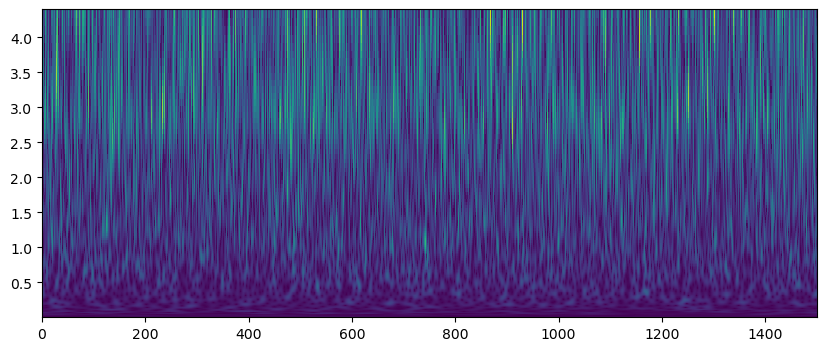

In [92]:
wf.plot_cwt(res.wt_amp, res.f, res.t)

Amplitude is very low, and oscillation at 3-Hz is hardly seen, but seen clearer after averaging over time:

[Text(0.5, 0, 'Frequency (Hz)'),
 Text(0, 0.5, 'Signal oscillation frequency (Hz)')]

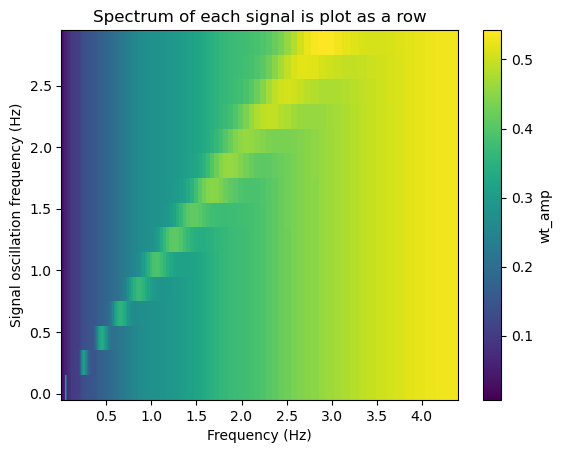

In [76]:
spectra.plot(y='fsig')
plt.title('Spectrum of each signal is plot as a row')
plt.gca().set(xlabel='Frequency (Hz)', ylabel='Signal oscillation frequency (Hz)')

[Text(0.5, 0, 'Frequency (Hz)'), Text(0, 0.5, 'Wavelet amplitude')]

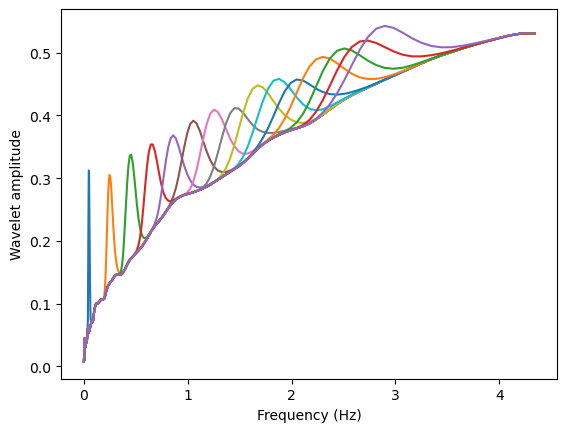

In [77]:
spectra.plot.line(hue='fsig', add_legend=False);
plt.gca().set(xlabel='Frequency (Hz)', ylabel='Wavelet amplitude')

# Wavelet amplitude spectrum has a background growing with frequency due to the white noise added to the signal (sqrt(f) dependence due to L1 norm). The smaller the signal oscillation amplitude, the closer the oscillation's wavelet amplitude (peak top) is to the noise background, i.e., the stronger is the dependence of the peak top height on frequency.